In [1]:
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

df = pd.read_csv("../user_movie_rates.csv")
df.head()

,user_id,movie_id,rating,datetime
0,1,1193,5,2000-12-31 22:12:40+00:00
1,1,661,3,2000-12-31 22:35:09+00:00
2,1,914,3,2000-12-31 22:32:48+00:00
3,1,3408,4,2000-12-31 22:04:35+00:00
4,1,2355,5,2001-01-06 23:38:11+00:00


In [2]:
print(df.columns)
print(df.shape)

Index(['user_id', 'movie_id', 'rating', 'datetime'], dtype='str')
(948367, 4)


In [3]:
df["rating"].value_counts().sort_index()

rating
1     52181
2    101962
3    248585
4    331604
5    214035
Name: count, dtype: int64

In [4]:
!pip install implicit


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Построение положительных взаимодействий

Все оценки, превышающие порог, интерпретируются как положительное взаимодействие пользователя с фильмом. Такой подход широко применяется в рекомендательных системах, поскольку implicit feedback лучше подходит для задач ранжирования.

### Фильтрация пользователей по числу взаимодействий

Пользователи с очень малым количеством взаимодействий содержат недостаточно информации для обучения модели.
Поэтому вводится параметр `min_pos`, задающий **минимальное количество положительных взаимодействий пользователя**.
Пользователи, у которых число взаимодействий меньше данного порога, удаляются из датасета. Это позволяет повысить качество обучения и уменьшить влияние шумовых данных.

In [5]:
from common.data_prep import build_edges, filter_users_min_pos

THRESHOLDS = [3.0, 4.0]
MIN_POS_LIST = [5, 10, 20]
LAST_N_LIST = [1, 2]
experiments = {}

for threshold in THRESHOLDS:
    edges_thr = build_edges(df, threshold=threshold)

    for min_pos in MIN_POS_LIST:
        edges = filter_users_min_pos(edges_thr, min_pos=min_pos)

        exp_name = f"thr_{threshold:.1f}_minpos_{min_pos}"
        experiments[exp_name] = {
            "threshold": threshold,
            "min_pos": min_pos,
            "edges": edges,
        }

        print(
            f"{exp_name}: "
            f"edges={len(edges)}, "
            f"users={edges['user_id'].nunique()}, "
            f"movies={edges['movie_id'].nunique()}"
        )

thr_3.0_minpos_5: edges=794223, users=6038, movies=3264
thr_3.0_minpos_10: edges=794183, users=6033, movies=3264
thr_3.0_minpos_20: edges=788215, users=5673, movies=3261
thr_4.0_minpos_5: edges=545628, users=6033, movies=3197
thr_4.0_minpos_10: edges=544897, users=5937, movies=3196
thr_4.0_minpos_20: edges=531904, users=5083, movies=3189


### Разделение данных на обучающую и тестовую выборки

Для оценки качества рекомендаций данные разделяются на обучающую и тестовую части.

Используется временное разделение (temporal split): последние `n` взаимодействий каждого пользователя помещаются в тестовую выборку, а остальные используются для обучения.
Такой подход имитирует реальный сценарий работы рекомендательной системы, в котором необходимо предсказывать будущие интересы пользователя на основе его прошлых действий.

In [6]:
from common.split import time_split_last_n

splits = {}

for exp_name, exp_data in experiments.items():
    edges = exp_data["edges"]

    for last_n in LAST_N_LIST:
        train_df, test_df = time_split_last_n(edges, last_n=last_n)

        splits[(exp_name, last_n)] = {
            "train": train_df,
            "test": test_df,
            "threshold": exp_data["threshold"],
            "min_pos": exp_data["min_pos"],
            "last_n": last_n,
        }

        print(
            f"{exp_name}, last_n={last_n}: "
            f"train={len(train_df)}, "
            f"test={len(test_df)}, "
            f"train_users={train_df['user_id'].nunique()}, "
            f"test_users={test_df['user_id'].nunique()}"
        )

thr_3.0_minpos_5, last_n=1: train=788185, test=6038, train_users=6038, test_users=6038
thr_3.0_minpos_5, last_n=2: train=782147, test=12076, train_users=6038, test_users=6038
thr_3.0_minpos_10, last_n=1: train=788150, test=6033, train_users=6033, test_users=6033
thr_3.0_minpos_10, last_n=2: train=782117, test=12066, train_users=6033, test_users=6033
thr_3.0_minpos_20, last_n=1: train=782542, test=5673, train_users=5673, test_users=5673
thr_3.0_minpos_20, last_n=2: train=776869, test=11346, train_users=5673, test_users=5673
thr_4.0_minpos_5, last_n=1: train=539595, test=6033, train_users=6033, test_users=6033
thr_4.0_minpos_5, last_n=2: train=533562, test=12066, train_users=6033, test_users=6033
thr_4.0_minpos_10, last_n=1: train=538960, test=5937, train_users=5937, test_users=5937
thr_4.0_minpos_10, last_n=2: train=533023, test=11874, train_users=5937, test_users=5937
thr_4.0_minpos_20, last_n=1: train=526821, test=5083, train_users=5083, test_users=5083
thr_4.0_minpos_20, last_n=2: tr

In [7]:
stats = []

for (exp_name, last_n), split_data in splits.items():
    train_df = split_data["train"]
    test_df = split_data["test"]

    stats.append({
        "experiment": exp_name,
        "threshold": split_data["threshold"],
        "min_pos": split_data["min_pos"],
        "last_n": split_data["last_n"],
        "train_edges": len(train_df),
        "test_edges": len(test_df),
        "train_users": train_df["user_id"].nunique(),
        "test_users": test_df["user_id"].nunique(),
        "train_movies": train_df["movie_id"].nunique(),
        "test_movies": test_df["movie_id"].nunique(),
    })

stats_df = pd.DataFrame(stats).sort_values(
    ["threshold", "min_pos", "last_n"]
).reset_index(drop=True)

stats_df

,experiment,threshold,min_pos,last_n,train_edges,test_edges,train_users,test_users,train_movies,test_movies
0,thr_3.0_minpos_5,3.0,5,1,788185,6038,6038,6038,3261,1783
1,thr_3.0_minpos_5,3.0,5,2,782147,12076,6038,6038,3259,2252
2,thr_3.0_minpos_10,3.0,10,1,788150,6033,6033,6033,3261,1783
3,thr_3.0_minpos_10,3.0,10,2,782117,12066,6033,6033,3259,2252
4,thr_3.0_minpos_20,3.0,20,1,782542,5673,5673,5673,3258,1758
5,thr_3.0_minpos_20,3.0,20,2,776869,11346,5673,5673,3256,2234
6,thr_4.0_minpos_5,4.0,5,1,539595,6033,6033,6033,3194,1734
7,thr_4.0_minpos_5,4.0,5,2,533562,12066,6033,6033,3190,2149
8,thr_4.0_minpos_10,4.0,10,1,538960,5937,5937,5937,3193,1725
9,thr_4.0_minpos_10,4.0,10,2,533023,11874,5937,5937,3189,2145


In [8]:
exp_name = "thr_3.0_minpos_5"
last_n = 1

train_df = splits[(exp_name, last_n)]["train"]
test_df = splits[(exp_name, last_n)]["test"]

train_df.head(), test_df.head()

(   user_id  movie_id                  datetime
 0        1      3186 2000-12-31 22:00:19+00:00
 1        1      1270 2000-12-31 22:00:55+00:00
 2        1      1721 2000-12-31 22:00:55+00:00
 3        1      1022 2000-12-31 22:00:55+00:00
 4        1      2340 2000-12-31 22:01:43+00:00,
    user_id  movie_id                  datetime
 0        1        48 2001-01-06 23:39:11+00:00
 1        2      1917 2000-12-31 22:02:54+00:00
 2        3      2081 2000-12-31 21:35:04+00:00
 3        4      1954 2000-12-31 20:24:42+00:00
 4        5      1884 2000-12-31 07:09:36+00:00)

### Индексация пользователей и фильмов

Модели факторизации матриц работают с числовыми индексами, а не с исходными идентификаторами пользователей и фильмов.

Поэтому создаются специальные отображения:

- `user2idx` — отображение `user_id` -> индекс строки матрицы
- `idx2user` — обратное отображение индекса в `user_id`
- `item2idx` — отображение `movie_id` -> индекс столбца матрицы
- `idx2item` — обратное отображение индекса в `movie_id`

Эти структуры позволяют эффективно работать с матрицей взаимодействий.

In [9]:
from common.indexing import build_index_maps, build_interaction_matrix

matrices = {}

for (exp_name, last_n), split_data in splits.items():
    train_df = split_data["train"]
    test_df = split_data["test"]

    user2idx, idx2user, item2idx, idx2item = build_index_maps(train_df)
    X = build_interaction_matrix(train_df, user2idx, item2idx)

    matrices[(exp_name, last_n)] = {
        "X": X,
        "user2idx": user2idx,
        "idx2user": idx2user,
        "item2idx": item2idx,
        "idx2item": idx2item,
        "train": train_df,
        "test": test_df,
        "threshold": split_data["threshold"],
        "min_pos": split_data["min_pos"],
        "last_n": split_data["last_n"],
    }

    print(
        f"{exp_name}, last_n={last_n}: "
        f"X.shape={X.shape}, nnz={X.nnz}"
    )

thr_3.0_minpos_5, last_n=1: X.shape=(6038, 3261), nnz=788185
thr_3.0_minpos_5, last_n=2: X.shape=(6038, 3259), nnz=782147
thr_3.0_minpos_10, last_n=1: X.shape=(6033, 3261), nnz=788150
thr_3.0_minpos_10, last_n=2: X.shape=(6033, 3259), nnz=782117
thr_3.0_minpos_20, last_n=1: X.shape=(5673, 3258), nnz=782542
thr_3.0_minpos_20, last_n=2: X.shape=(5673, 3256), nnz=776869
thr_4.0_minpos_5, last_n=1: X.shape=(6033, 3194), nnz=539595
thr_4.0_minpos_5, last_n=2: X.shape=(6033, 3190), nnz=533562
thr_4.0_minpos_10, last_n=1: X.shape=(5937, 3193), nnz=538960
thr_4.0_minpos_10, last_n=2: X.shape=(5937, 3189), nnz=533023
thr_4.0_minpos_20, last_n=1: X.shape=(5083, 3186), nnz=526821
thr_4.0_minpos_20, last_n=2: X.shape=(5083, 3183), nnz=521738


In [10]:
exp_name = "thr_3.0_minpos_5"
last_n = 1

bundle = matrices[(exp_name, last_n)]

X = bundle["X"]
train_df = bundle["train"]
test_df = bundle["test"]
user2idx = bundle["user2idx"]
idx2item = bundle["idx2item"]

### Обучение модели факторизации матриц

Для построения рекомендательной модели используется алгоритм Alternating Least Squares (ALS) для неявной обратной связи.

Метод факторизации матриц предполагает, что пользователи и фильмы могут быть представлены в виде векторов в скрытом (латентном) пространстве.
Каждому пользователю соответствует вектор предпочтений, а каждому фильму — вектор характеристик.
Релевантность фильма пользователю определяется скалярным произведением этих векторов:

Алгоритм ALS итеративно оптимизирует эти векторы, минимизируя ошибку между наблюдаемыми и предсказанными взаимодействиями.

In [11]:
from implicit.als import AlternatingLeastSquares

def train_mf_als(
    user_item_matrix,
    factors: int = 64,
    regularization: float = 0.01,
    iterations: int = 20,
    alpha: float = 10.0,
    random_state: int = 42,
):
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        random_state=random_state,
    )

    user_item_conf = (user_item_matrix * alpha).tocsr()
    model.fit(user_item_conf)

    return model

/Users/alexandro/DataspellProjects/recommend-system/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
mf_model = train_mf_als(
    user_item_matrix=X,
    factors=64,
    regularization=0.01,
    iterations=20,
    alpha=10.0,
    random_state=42,
)

print("X.shape:", X.shape)
print("mf_model.user_factors.shape:", mf_model.user_factors.shape)
print("mf_model.item_factors.shape:", mf_model.item_factors.shape)

100%|██████████| 20/20 [00:02<00:00,  6.86it/s]

X.shape: (6038, 3261)
mf_model.user_factors.shape: (6038, 64)
mf_model.item_factors.shape: (3261, 64)


In [13]:
user_id = test_df["user_id"].iloc[0]
user_idx = user2idx[user_id]

rec_item_indices, rec_scores = mf_model.recommend(
    userid=user_idx,
    user_items=X[user_idx],
    N=10,
    filter_already_liked_items=True,
)

recommended_movie_ids = [idx2item[i] for i in rec_item_indices]
recommended_movie_ids

[np.int64(364),
 np.int64(1282),
 np.int64(2858),
 np.int64(596),
 np.int64(2096),
 np.int64(318),
 np.int64(1198),
 np.int64(1225),
 np.int64(2078),
 np.int64(593)]

In [14]:
user_test_movies = test_df.loc[test_df["user_id"] == user_id, "movie_id"].tolist()

print("Recommended:", recommended_movie_ids)
print("Test movies:", user_test_movies)
print("Hits:", set(recommended_movie_ids) & set(user_test_movies))

Recommended: [np.int64(364), np.int64(1282), np.int64(2858), np.int64(596), np.int64(2096), np.int64(318), np.int64(1198), np.int64(1225), np.int64(2078), np.int64(593)]
Test movies: [48]
Hits: set()


In [15]:
def recommend_mf(model, X, user2idx, idx2item, users, k=10):
    recommendations = {}

    for user_id in users:
        if user_id not in user2idx:
            continue

        user_idx = user2idx[user_id]

        rec_item_indices, rec_scores = model.recommend(
            userid=user_idx,
            user_items=X[user_idx],
            N=k,
            filter_already_liked_items=True,
        )

        recommendations[user_id] = [idx2item[i] for i in rec_item_indices]

    return recommendations

In [16]:
from common.eval import build_user_item_dict

test_user_items = build_user_item_dict(test_df)
test_users = list(test_user_items.keys())

In [17]:
recommendations = recommend_mf(
    model=mf_model,
    X=X,
    user2idx=user2idx,
    idx2item=idx2item,
    users=test_users,
    k=10,
)

In [18]:
from common.eval import evaluate_ranking

metrics = evaluate_ranking(
    recommendations=recommendations,
    ground_truth=test_user_items,
    k=10,
)

metrics

{'precision': np.float64(0.008893673401788673),
 'recall': np.float64(0.08893673401788672),
 'map': np.float64(0.029619946686856257),
 'ndcg': np.float64(0.04329468958947451),
 'mrr': np.float64(0.029619946686856257),
 'hitrate': np.float64(0.08893673401788672)}

In [19]:
mf_results = []

for (exp_name, last_n), bundle in matrices.items():
    X = bundle["X"]
    test_df = bundle["test"]
    user2idx = bundle["user2idx"]
    idx2item = bundle["idx2item"]

    mf_model = train_mf_als(
        user_item_matrix=X,
        factors=64,
        regularization=0.01,
        iterations=20,
        alpha=10.0,
        random_state=42,
    )

    test_user_items = build_user_item_dict(test_df)

    recommendations = recommend_mf(
        model=mf_model,
        X=X,
        user2idx=user2idx,
        idx2item=idx2item,
        users=list(test_user_items.keys()),
        k=10,
    )

    metrics = evaluate_ranking(
        recommendations=recommendations,
        ground_truth=test_user_items,
        k=10,
    )

    mf_results.append({
        "experiment": exp_name,
        "last_n": last_n,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "map": metrics["map"],
        "ndcg": metrics["ndcg"],
        "mrr": metrics["mrr"],
        "hitrate": metrics["hitrate"],
        "train_edges": bundle["train"].shape[0],
        "test_edges": bundle["test"].shape[0],
        "graph_nodes": X.shape[0] + X.shape[1],
    })

100%|██████████| 20/20 [00:02<00:00,  9.22it/s]


In [20]:
mf_results_df = pd.DataFrame(mf_results)
mf_results_df.sort_values(["recall", "ndcg"], ascending=False)

,experiment,last_n,precision,recall,map,ndcg,mrr,hitrate,train_edges,test_edges,graph_nodes
6,thr_4.0_minpos_5,1,0.009431,0.094315,0.032883,0.046987,0.032883,0.094315,539595,6033,9227
2,thr_3.0_minpos_10,1,0.009233,0.092326,0.028921,0.043458,0.028921,0.092326,788150,6033,9294
7,thr_4.0_minpos_5,2,0.018299,0.091497,0.032607,0.055118,0.058806,0.166915,533562,12066,9223
9,thr_4.0_minpos_10,2,0.018208,0.091039,0.032404,0.054628,0.057826,0.163719,533023,11874,9126
0,thr_3.0_minpos_5,1,0.008894,0.088937,0.029620,0.043295,0.029620,0.088937,788185,6038,9299
8,thr_4.0_minpos_10,1,0.008860,0.088597,0.031692,0.044813,0.031692,0.088597,538960,5937,9130
1,thr_3.0_minpos_5,2,0.017440,0.087198,0.030625,0.052170,0.055450,0.157999,782147,12076,9297
3,thr_3.0_minpos_10,2,0.017338,0.086690,0.030462,0.051857,0.055183,0.158130,782117,12066,9292
4,thr_3.0_minpos_20,1,0.007844,0.078442,0.026086,0.038140,0.026086,0.078442,782542,5673,8931
5,thr_3.0_minpos_20,2,0.015547,0.077737,0.027718,0.046898,0.050332,0.141548,776869,11346,8929


In [21]:
import matplotlib.pyplot as plt

df = mf_results_df.copy()

df["threshold"] = df["experiment"].str.extract(r"thr_(\d+\.\d+)").astype(float)
df["min_pos"] = df["experiment"].str.extract(r"minpos_(\d+)").astype(int)

numeric_cols = [
    "precision","recall","map","ndcg","mrr","hitrate",
    "train_edges","test_edges","graph_nodes","last_n"
]

for c in numeric_cols:
    df[c] = df[c].astype(float)

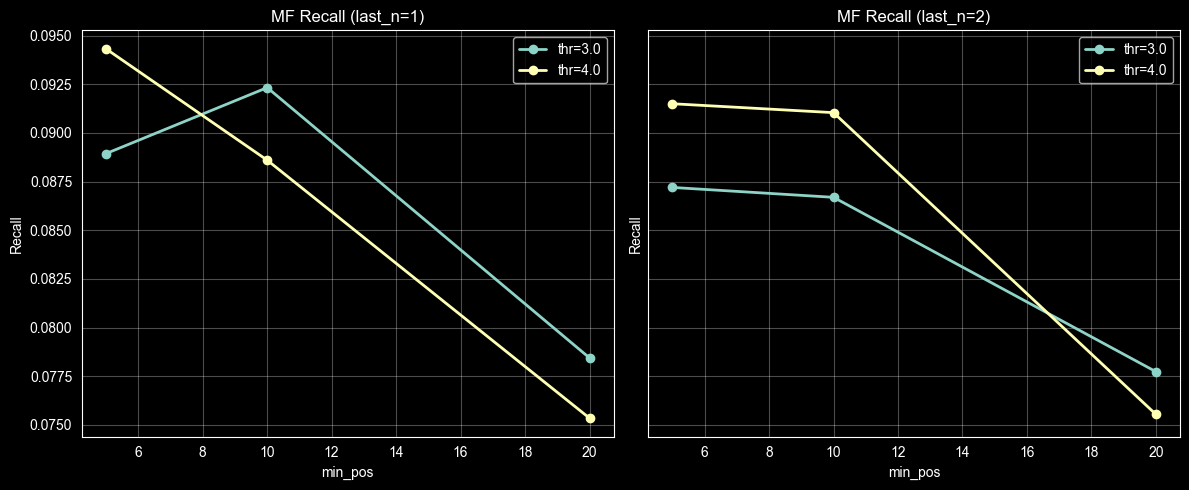

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for ax, last_n in zip(axes, [1,2]):

    subset = df[df["last_n"] == last_n]

    for thr in sorted(subset["threshold"].unique()):
        tmp = subset[subset["threshold"] == thr].sort_values("min_pos")

        ax.plot(
            tmp["min_pos"],
            tmp["recall"],
            marker="o",
            linewidth=2,
            label=f"thr={thr}"
        )

    ax.set_title(f"MF Recall (last_n={last_n})")
    ax.set_xlabel("min_pos")
    ax.set_ylabel("Recall")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

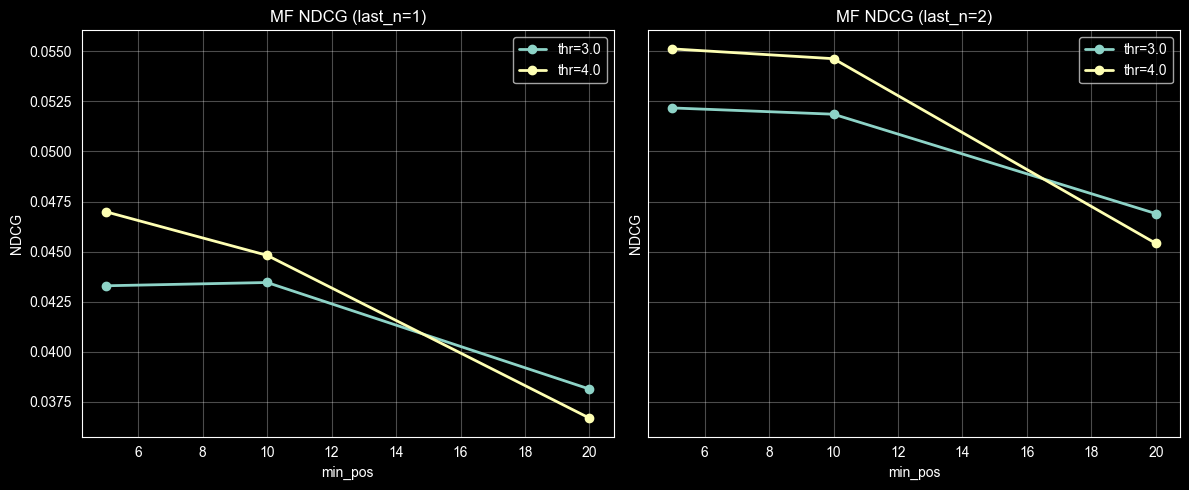

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for ax, last_n in zip(axes, [1,2]):

    subset = df[df["last_n"] == last_n]

    for thr in sorted(subset["threshold"].unique()):
        tmp = subset[subset["threshold"] == thr].sort_values("min_pos")

        ax.plot(
            tmp["min_pos"],
            tmp["ndcg"],
            marker="o",
            linewidth=2,
            label=f"thr={thr}"
        )

    ax.set_title(f"MF NDCG (last_n={last_n})")
    ax.set_xlabel("min_pos")
    ax.set_ylabel("NDCG")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

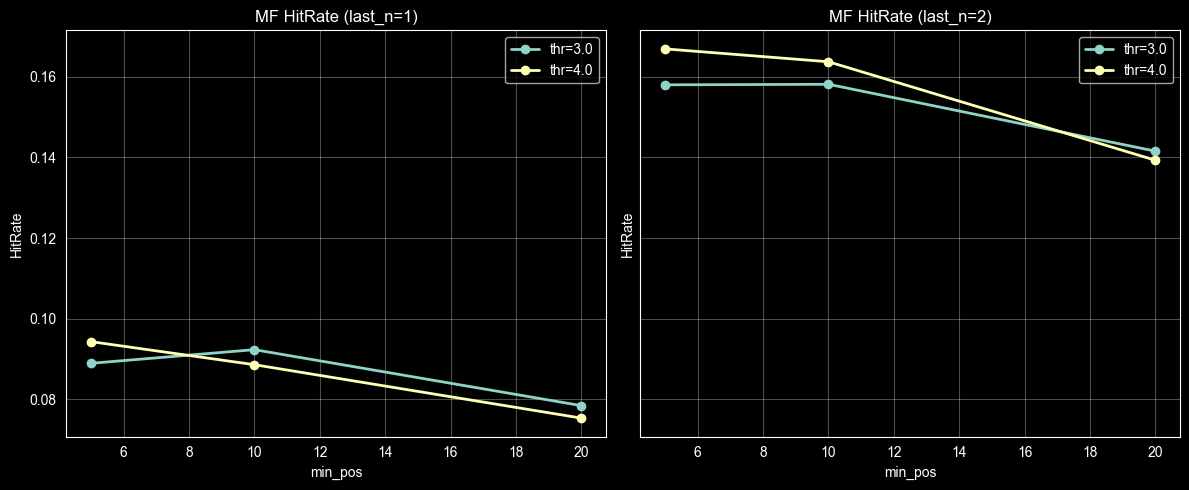

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for ax, last_n in zip(axes, [1,2]):

    subset = df[df["last_n"] == last_n]

    for thr in sorted(subset["threshold"].unique()):
        tmp = subset[subset["threshold"] == thr].sort_values("min_pos")

        ax.plot(
            tmp["min_pos"],
            tmp["hitrate"],
            marker="o",
            linewidth=2,
            label=f"thr={thr}"
        )

    ax.set_title(f"MF HitRate (last_n={last_n})")
    ax.set_xlabel("min_pos")
    ax.set_ylabel("HitRate")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [25]:
FACTORS_LIST = [64, 128, 256]
REG_LIST = [0.01, 0.05, 0.1]
ALPHA_LIST = [5, 10, 20, 40]
ITER_LIST = [20, 30, 40]

USE_BM25_LIST = [False, True]
BM25_K1_LIST = [10, 50, 100]
BM25_B_LIST = [0.5, 0.8, 1.0]

In [26]:
mf_tuning_results = []

for exp_name, last_n in list(matrices.keys()):
    bundle = matrices[(exp_name, last_n)]

    X = bundle["X"]
    test_df = bundle["test"]
    user2idx = bundle["user2idx"]
    idx2item = bundle["idx2item"]

    test_user_items = build_user_item_dict(test_df)
    test_users = list(test_user_items.keys())

    for factors in FACTORS_LIST:
        for reg in REG_LIST:
            for alpha in ALPHA_LIST:
                for n_iter in ITER_LIST:
                    try:
                        mf_model = train_mf_als(
                            user_item_matrix=X,
                            factors=factors,
                            regularization=reg,
                            iterations=n_iter,
                            alpha=alpha,
                            random_state=42,
                        )

                        recommendations = recommend_mf(
                            model=mf_model,
                            X=X,
                            user2idx=user2idx,
                            idx2item=idx2item,
                            users=test_users,
                            k=10,
                        )

                        metrics = evaluate_ranking(
                            recommendations=recommendations,
                            ground_truth=test_user_items,
                            k=10,
                        )

                        mf_tuning_results.append({
                            "experiment": exp_name,
                            "last_n": last_n,
                            "use_bm25": False,
                            "bm25_k1": None,
                            "bm25_b": None,
                            "factors": factors,
                            "regularization": reg,
                            "alpha": alpha,
                            "iterations": n_iter,
                            "precision": metrics["precision"],
                            "recall": metrics["recall"],
                            "map": metrics["map"],
                            "ndcg": metrics["ndcg"],
                            "mrr": metrics["mrr"],
                            "hitrate": metrics["hitrate"],
                            "train_edges": len(bundle["train"]),
                            "test_edges": len(bundle["test"]),
                            "graph_nodes": X.shape[0] + X.shape[1],
                        })

                    except Exception as e:
                        mf_tuning_results.append({
                            "experiment": exp_name,
                            "last_n": last_n,
                            "use_bm25": False,
                            "bm25_k1": None,
                            "bm25_b": None,
                            "factors": factors,
                            "regularization": reg,
                            "alpha": alpha,
                            "iterations": n_iter,
                            "precision": None,
                            "recall": None,
                            "map": None,
                            "ndcg": None,
                            "mrr": None,
                            "hitrate": None,
                            "error": str(e),
                        })

100%|██████████| 40/40 [00:14<00:00,  2.67it/s]


In [29]:
mf_tuning_df = pd.DataFrame(mf_tuning_results)
mf_tuning_df.sort_values(["recall", "ndcg"], ascending=False)

,experiment,last_n,use_bm25,bm25_k1,bm25_b,factors,regularization,alpha,iterations,precision,recall,map,ndcg,mrr,hitrate,train_edges,test_edges,graph_nodes
14,thr_3.0_minpos_5,1,False,None,None,64,0.05,5,40,0.009805,0.098046,0.032515,0.047592,0.032515,0.098046,788185,6038,9299
26,thr_3.0_minpos_5,1,False,None,None,64,0.10,5,40,0.009738,0.097383,0.032567,0.047492,0.032567,0.097383,788185,6038,9299
264,thr_3.0_minpos_10,1,False,None,None,128,0.05,5,20,0.009730,0.097298,0.032624,0.047519,0.032624,0.097298,788150,6033,9294
252,thr_3.0_minpos_10,1,False,None,None,128,0.01,5,20,0.009730,0.097298,0.032501,0.047407,0.032501,0.097298,788150,6033,9294
217,thr_3.0_minpos_10,1,False,None,None,64,0.01,5,30,0.009730,0.097298,0.031940,0.046923,0.031940,0.097298,788150,6033,9294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,thr_4.0_minpos_20,1,False,None,None,256,0.01,20,40,0.006492,0.064922,0.021627,0.031602,0.021627,0.064922,526821,5083,8269
1222,thr_4.0_minpos_20,2,False,None,None,64,0.10,40,30,0.012906,0.064529,0.021821,0.037879,0.039908,0.119614,521738,10166,8266
1221,thr_4.0_minpos_20,2,False,None,None,64,0.10,40,20,0.012866,0.064332,0.021763,0.037724,0.039646,0.119024,521738,10166,8266
1223,thr_4.0_minpos_20,2,False,None,None,64,0.10,40,40,0.012670,0.063348,0.021488,0.037248,0.039148,0.117254,521738,10166,8266


In [30]:
df = mf_tuning_df.copy()

df["threshold"] = df["experiment"].str.extract(r"thr_(\d+\.\d+)").astype(float)
df["min_pos"] = df["experiment"].str.extract(r"minpos_(\d+)").astype(int)

df = df.sort_values(
    ["experiment", "last_n", "use_bm25", "factors", "regularization", "alpha", "iterations"]
).reset_index(drop=True)

df.head()

,experiment,last_n,use_bm25,bm25_k1,bm25_b,factors,regularization,alpha,iterations,precision,recall,map,ndcg,mrr,hitrate,train_edges,test_edges,graph_nodes,threshold,min_pos
0,thr_3.0_minpos_10,1,False,None,None,64,0.01,5,20,0.009547,0.095475,0.031217,0.045971,0.031217,0.095475,788150,6033,9294,3.0,10
1,thr_3.0_minpos_10,1,False,None,None,64,0.01,5,30,0.009730,0.097298,0.031940,0.046923,0.031940,0.097298,788150,6033,9294,3.0,10
2,thr_3.0_minpos_10,1,False,None,None,64,0.01,5,40,0.009547,0.095475,0.031901,0.046507,0.031901,0.095475,788150,6033,9294,3.0,10
3,thr_3.0_minpos_10,1,False,None,None,64,0.01,10,20,0.009233,0.092326,0.028921,0.043458,0.028921,0.092326,788150,6033,9294,3.0,10
4,thr_3.0_minpos_10,1,False,None,None,64,0.01,10,30,0.009034,0.090336,0.029281,0.043301,0.029281,0.090336,788150,6033,9294,3.0,10


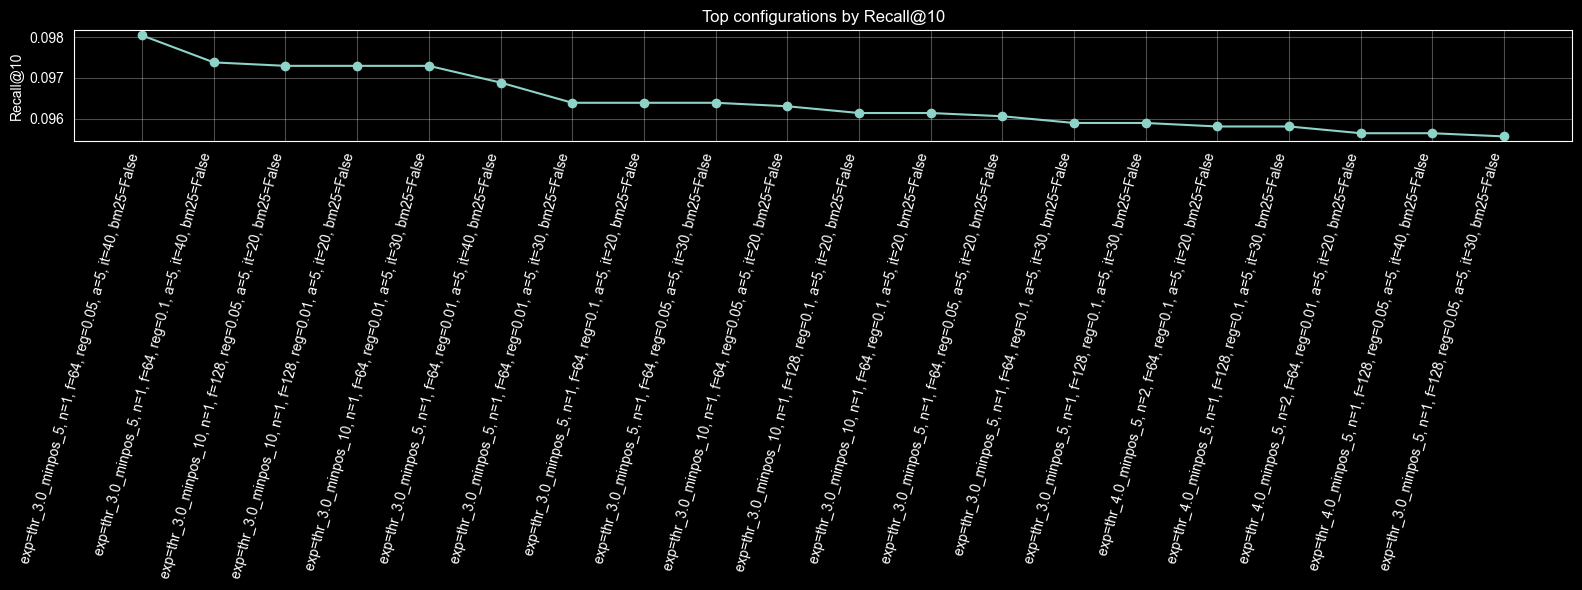

In [33]:
top_n = 20

top_df = df.sort_values(["recall", "ndcg"], ascending=False).head(top_n).copy()

top_df["label"] = (
    "exp=" + top_df["experiment"]
    + ", n=" + top_df["last_n"].astype(str)
    + ", f=" + top_df["factors"].astype(str)
    + ", reg=" + top_df["regularization"].astype(str)
    + ", a=" + top_df["alpha"].astype(str)
    + ", it=" + top_df["iterations"].astype(str)
    + ", bm25=" + top_df["use_bm25"].astype(str)
)

plt.figure(figsize=(16, 6))
plt.plot(top_df["label"], top_df["recall"], marker="o")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Recall@10")
plt.title("Top configurations by Recall@10")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

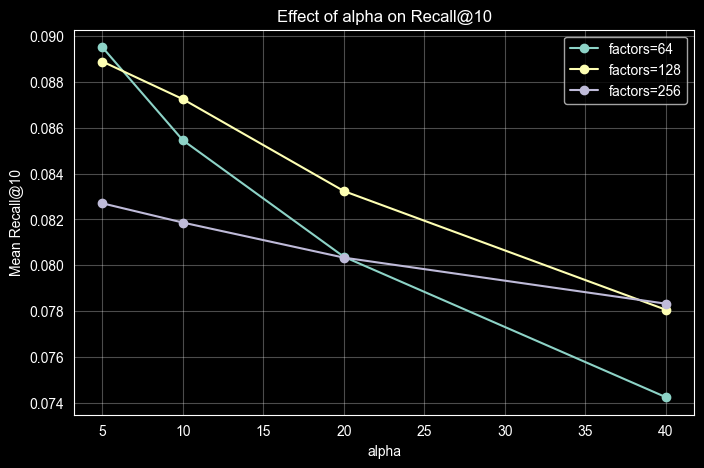

In [35]:
plt.figure(figsize=(8, 5))

for factors in sorted(df["factors"].unique()):
    tmp = (
        df.groupby(["alpha", "factors"], as_index=False)["recall"]
          .mean()
    )
    tmp = tmp[tmp["factors"] == factors].sort_values("alpha")

    plt.plot(tmp["alpha"], tmp["recall"], marker="o", label=f"factors={factors}")

plt.xlabel("alpha")
plt.ylabel("Mean Recall@10")
plt.title("Effect of alpha on Recall@10")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

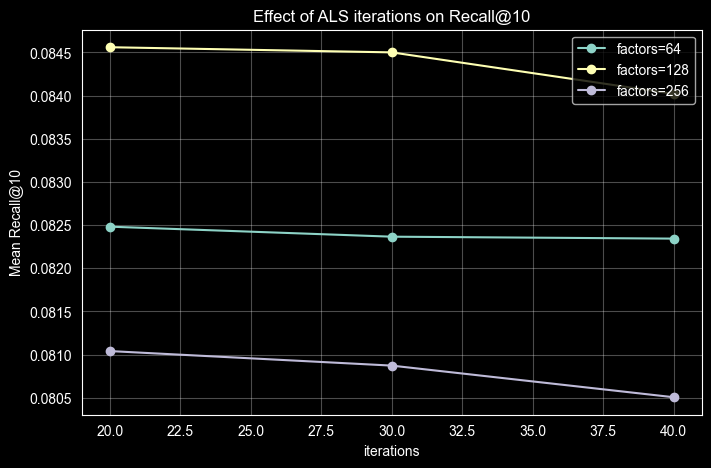

In [37]:
plt.figure(figsize=(8, 5))

for factors in sorted(df["factors"].unique()):
    tmp = (
        df.groupby(["iterations", "factors"], as_index=False)["recall"]
          .mean()
    )
    tmp = tmp[tmp["factors"] == factors].sort_values("iterations")

    plt.plot(tmp["iterations"], tmp["recall"], marker="o", label=f"factors={factors}")

plt.xlabel("iterations")
plt.ylabel("Mean Recall@10")
plt.title("Effect of ALS iterations on Recall@10")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

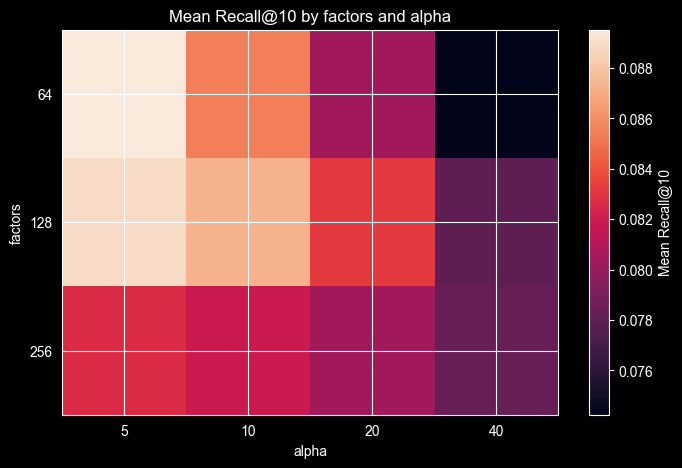

In [39]:
plt.figure(figsize=(8, 5))
plt.imshow(pivot_recall, aspect="auto")
plt.xticks(range(len(pivot_recall.columns)), pivot_recall.columns)
plt.yticks(range(len(pivot_recall.index)), pivot_recall.index)
plt.colorbar(label="Mean Recall@10")
plt.xlabel("alpha")
plt.ylabel("factors")
plt.title("Mean Recall@10 by factors and alpha")
plt.show()

In [41]:
best_configs = df.sort_values(
    ["recall", "ndcg", "hitrate"],
    ascending=False
)

best_configs[cols_to_show].head(10)

,experiment,last_n,use_bm25,bm25_k1,bm25_b,factors,regularization,alpha,iterations,precision,recall,map,ndcg,mrr,hitrate
446,thr_3.0_minpos_5,1,False,None,None,64,0.05,5,40,0.009805,0.098046,0.032515,0.047592,0.032515,0.098046
458,thr_3.0_minpos_5,1,False,None,None,64,0.10,5,40,0.009738,0.097383,0.032567,0.047492,0.032567,0.097383
48,thr_3.0_minpos_10,1,False,None,None,128,0.05,5,20,0.009730,0.097298,0.032624,0.047519,0.032624,0.097298
36,thr_3.0_minpos_10,1,False,None,None,128,0.01,5,20,0.009730,0.097298,0.032501,0.047407,0.032501,0.097298
1,thr_3.0_minpos_10,1,False,None,None,64,0.01,5,30,0.009730,0.097298,0.031940,0.046923,0.031940,0.097298
434,thr_3.0_minpos_5,1,False,None,None,64,0.01,5,40,0.009689,0.096886,0.032592,0.047391,0.032592,0.096886
433,thr_3.0_minpos_5,1,False,None,None,64,0.01,5,30,0.009639,0.096390,0.032238,0.047005,0.032238,0.096390
456,thr_3.0_minpos_5,1,False,None,None,64,0.10,5,20,0.009639,0.096390,0.032209,0.046989,0.032209,0.096390
445,thr_3.0_minpos_5,1,False,None,None,64,0.05,5,30,0.009639,0.096390,0.032015,0.046850,0.032015,0.096390
12,thr_3.0_minpos_10,1,False,None,None,64,0.05,5,20,0.009630,0.096304,0.031099,0.046044,0.031099,0.096304
